# Butterfly Wing-Color Evolution — Exploratory Data Analysis

Comparative EDA of 5 GAMA experiment runs (`Project_01.gaml`), each simulating single-locus,
two-allele (B/W) wing-color genetics under predation for 1000 cycles.

| Experiment | Mechanism | Key parameter |
|---|---|---|
| **Base_Model** | Static gradual environment gradient, uniform predation | `base_capture_proba=0.6` |
| **Extension1_FrequencyDependentPredation** | Predators preferentially hunt the most common color class | `frequency_dependent_predation=true` |
| **Extension2_DynamicEnvironment** | Environment gradient slides across the grid over time | `env_change_speed=0.1` |
| **Extension3_HighPredation** | High baseline predation intensity | `base_capture_proba=0.9` |
| **Extension3_LowPredation** | Low baseline predation intensity | `base_capture_proba=0.15` |

Each CSV column: `cycle, length(butterfly), nb_reproductions, nb_deaths_predation, nb_deaths_natural,
nb_deaths_total, nb_black, nb_white, nb_gray, nb_BB, nb_WW, nb_BW, nb_allele_B, nb_allele_W`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = "."

EXPERIMENTS = {
    "Base_Model": "Base_Model_results.csv",
    "Ext1_FreqDependent": "Extension1_FrequencyDependentPredation_results.csv",
    "Ext2_DynamicEnv": "Extension2_DynamicEnvironment_results.csv",
    "Ext3_HighPredation": "Extension3_HighPredation_results.csv",
    "Ext3_LowPredation": "Extension3_LowPredation_results.csv",
}

COLORS = {
    "Base_Model": "#4C72B0",
    "Ext1_FreqDependent": "#DD8452",
    "Ext2_DynamicEnv": "#55A868",
    "Ext3_HighPredation": "#C44E52",
    "Ext3_LowPredation": "#8172B2",
}

dfs = {}
for name, fname in EXPERIMENTS.items():
    df = pd.read_csv(f"{DATA_DIR}/{fname}")
    df["freq_black"] = df["nb_black"] / df["length(butterfly)"]
    df["freq_white"] = df["nb_white"] / df["length(butterfly)"]
    df["freq_gray"] = df["nb_gray"] / df["length(butterfly)"]
    df["freq_allele_B"] = df["nb_allele_B"] / (df["nb_allele_B"] + df["nb_allele_W"])
    dfs[name] = df

print("Loaded experiments:", list(dfs.keys()))
for name, df in dfs.items():
    print(f"  {name}: {len(df)} cycles, columns={list(df.columns)[:5]}...")


Loaded experiments: ['Base_Model', 'Ext1_FreqDependent', 'Ext2_DynamicEnv', 'Ext3_HighPredation', 'Ext3_LowPredation']
  Base_Model: 1000 cycles, columns=['cycle', 'length(butterfly)', 'nb_reproductions', 'nb_deaths_predation', 'nb_deaths_natural']...
  Ext1_FreqDependent: 1000 cycles, columns=['cycle', 'length(butterfly)', 'nb_reproductions', 'nb_deaths_predation', 'nb_deaths_natural']...
  Ext2_DynamicEnv: 1000 cycles, columns=['cycle', 'length(butterfly)', 'nb_reproductions', 'nb_deaths_predation', 'nb_deaths_natural']...
  Ext3_HighPredation: 1000 cycles, columns=['cycle', 'length(butterfly)', 'nb_reproductions', 'nb_deaths_predation', 'nb_deaths_natural']...
  Ext3_LowPredation: 1000 cycles, columns=['cycle', 'length(butterfly)', 'nb_reproductions', 'nb_deaths_predation', 'nb_deaths_natural']...


## 1. Data quality check

Shape, dtypes, missing values, and duplicate-cycle check for every run.

In [2]:
summary_rows = []
for name, df in dfs.items():
    summary_rows.append({
        "experiment": name,
        "n_rows": len(df),
        "n_cols": df.shape[1],
        "cycle_min": df["cycle"].min(),
        "cycle_max": df["cycle"].max(),
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_cycles": int(df["cycle"].duplicated().sum()),
        "pop_min": df["length(butterfly)"].min(),
        "pop_max": df["length(butterfly)"].max(),
        "pop_final": df["length(butterfly)"].iloc[-1],
    })
quality_df = pd.DataFrame(summary_rows).set_index("experiment")
quality_df


,n_rows,n_cols,cycle_min,cycle_max,missing_values,duplicate_cycles,pop_min,pop_max,pop_final
experiment,,,,,,,,,
Base_Model,1000,18,0,999,0,0,200,600,600
Ext1_FreqDependent,1000,18,0,999,0,0,200,600,596
Ext2_DynamicEnv,1000,18,0,999,0,0,200,600,599
Ext3_HighPredation,1000,18,0,999,0,0,200,600,599
Ext3_LowPredation,1000,18,0,999,0,0,200,600,600


**Notes:** all 5 runs use identical initial conditions (200 butterflies, 50/50 allele
frequency, carrying capacity 600) and run for ~1000 cycles, so differences in outcome are
attributable to the varied mechanism only. No missing values or duplicate cycles found in any
file (headless runs, single seed).

## 2. Population dynamics over time

Total population trajectory — reproduction vs. carrying-capacity ceiling vs. predation pressure.

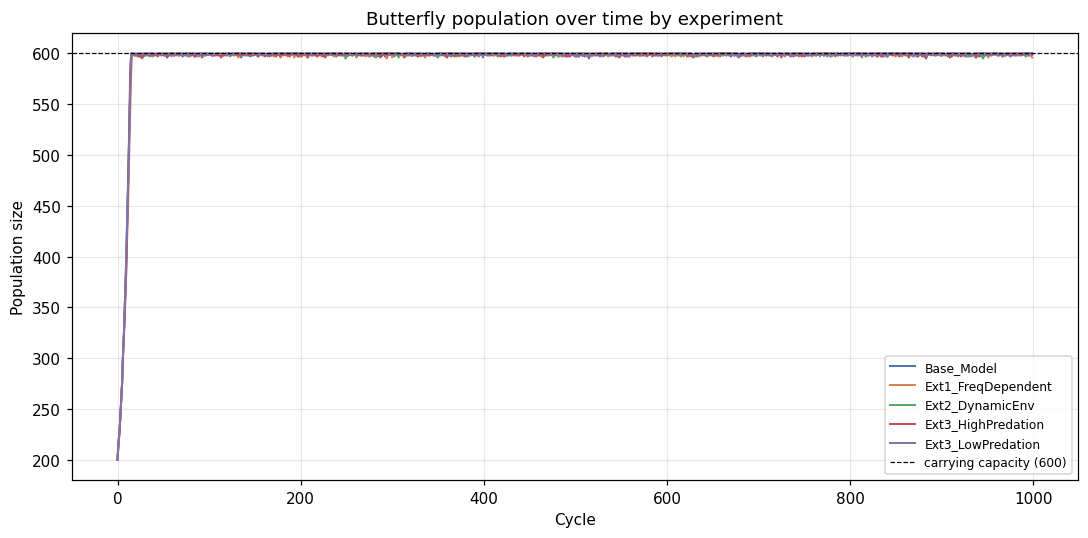

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in dfs.items():
    ax.plot(df["cycle"], df["length(butterfly)"], label=name, color=COLORS[name], linewidth=1.3)
ax.axhline(600, color="black", linestyle="--", linewidth=0.8, label="carrying capacity (600)")
ax.set_xlabel("Cycle")
ax.set_ylabel("Population size")
ax.set_title("Butterfly population over time by experiment")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("eda_population_dynamics.png", bbox_inches="tight")
plt.show()


## 3. Genotype / color-morph frequency trends

Fraction of population that is black (BB), white (WW), or gray (BW) over time — this is the selection signal.

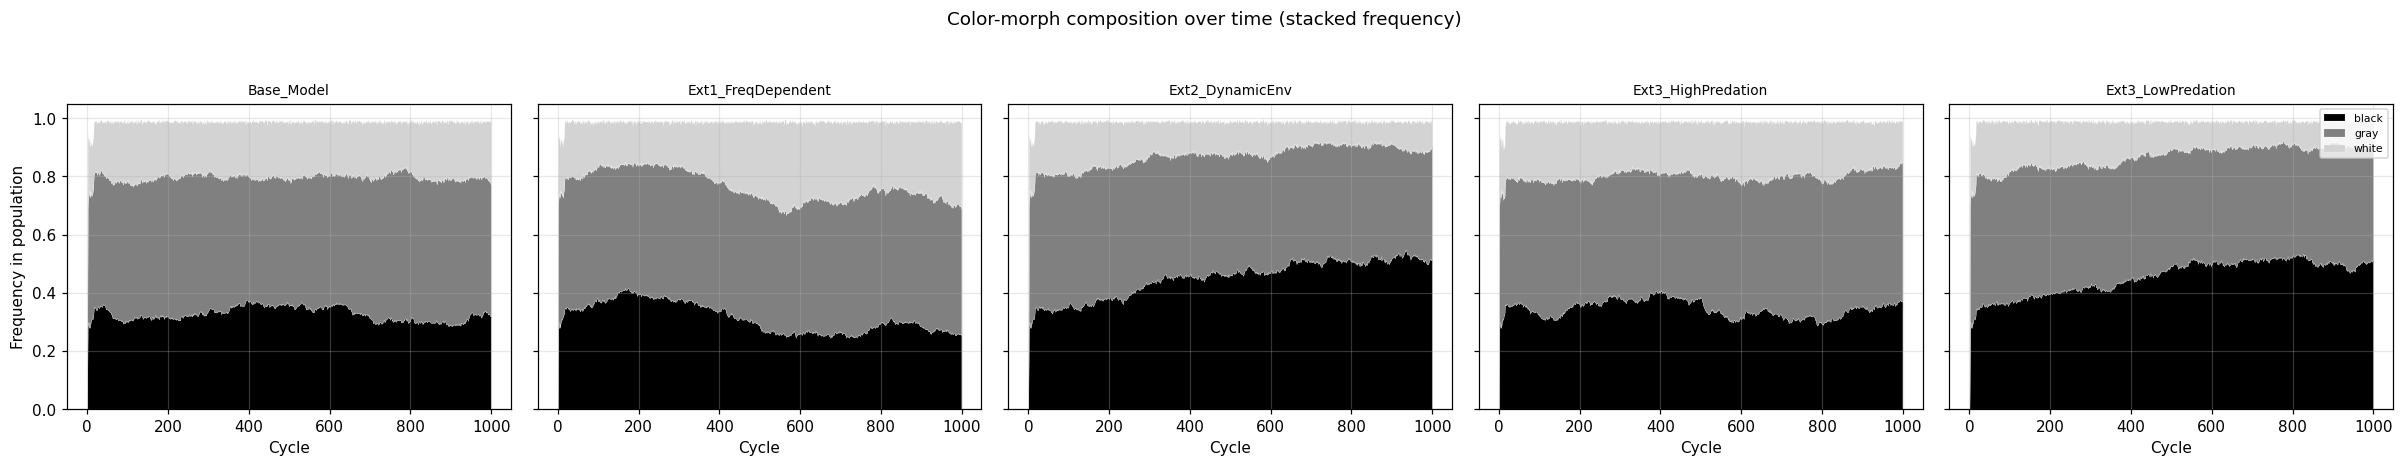

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
for ax, (name, df) in zip(axes, dfs.items()):
    ax.stackplot(df["cycle"], df["freq_black"], df["freq_gray"], df["freq_white"],
                 colors=["black", "gray", "lightgray"], edgecolor="white", linewidth=0.1,
                 labels=["black", "gray", "white"])
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("Cycle")
ax = axes[0]
ax.set_ylabel("Frequency in population")
axes[-1].legend(loc="upper right", fontsize=7)
plt.suptitle("Color-morph composition over time (stacked frequency)", y=1.05)
plt.tight_layout()
plt.savefig("eda_morph_composition.png", bbox_inches="tight")
plt.show()


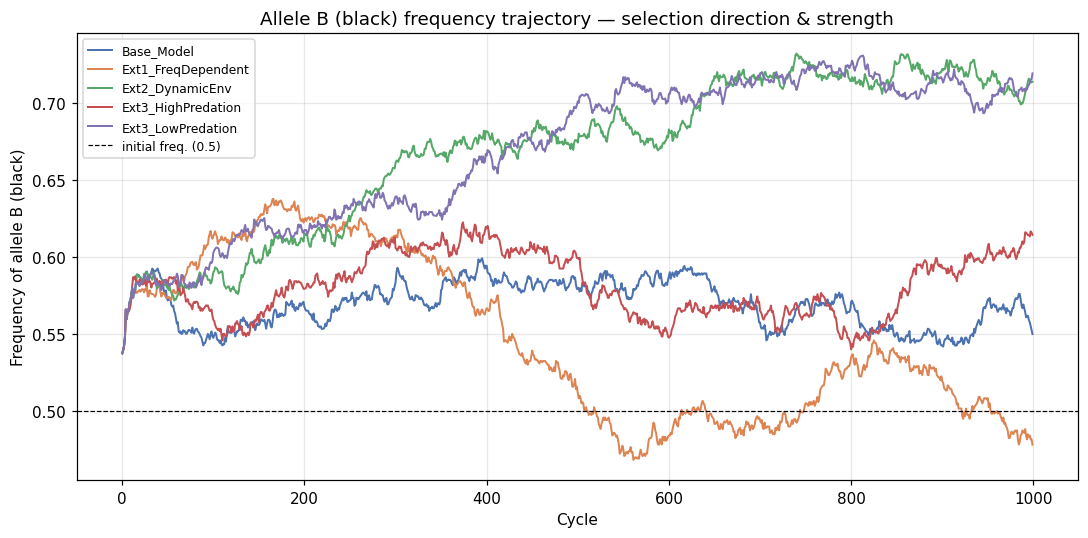

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in dfs.items():
    ax.plot(df["cycle"], df["freq_allele_B"], label=name, color=COLORS[name], linewidth=1.3)
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, label="initial freq. (0.5)")
ax.set_xlabel("Cycle")
ax.set_ylabel("Frequency of allele B (black)")
ax.set_title("Allele B (black) frequency trajectory — selection direction & strength")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("eda_allele_frequency.png", bbox_inches="tight")
plt.show()


## 4. Death-cause breakdown

Cumulative deaths by cause (predation vs. natural) — shows how strongly each mechanism drives mortality vs. background attrition.

In [6]:
cause_rows = []
for name, df in dfs.items():
    total_pred = df["nb_deaths_predation"].sum()
    total_nat = df["nb_deaths_natural"].sum()
    total_repro = df["nb_reproductions"].sum()
    cause_rows.append({
        "experiment": name,
        "total_reproductions": total_repro,
        "total_deaths_predation": total_pred,
        "total_deaths_natural": total_nat,
        "pct_deaths_from_predation": 100 * total_pred / (total_pred + total_nat),
        "mean_pop": df["length(butterfly)"].mean(),
    })
cause_df = pd.DataFrame(cause_rows).set_index("experiment")
cause_df


,total_reproductions,total_deaths_predation,total_deaths_natural,pct_deaths_from_predation,mean_pop
experiment,,,,,
Base_Model,7078,807,5871,12.084456,595.336
Ext1_FreqDependent,7180,823,5961,12.131486,595.188
Ext2_DynamicEnv,7097,721,5977,10.764407,595.401
Ext3_HighPredation,7184,863,5922,12.719234,595.262
Ext3_LowPredation,6608,367,5841,5.911727,595.751


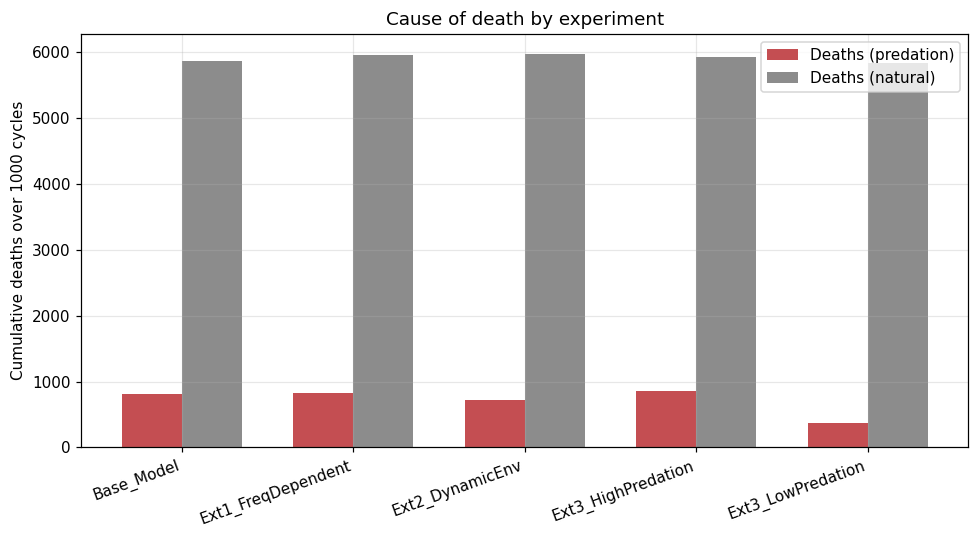

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(cause_df))
width = 0.35
ax.bar(x - width/2, cause_df["total_deaths_predation"], width, label="Deaths (predation)", color="#C44E52")
ax.bar(x + width/2, cause_df["total_deaths_natural"], width, label="Deaths (natural)", color="#8C8C8C")
ax.set_xticks(x)
ax.set_xticklabels(cause_df.index, rotation=20, ha="right")
ax.set_ylabel("Cumulative deaths over 1000 cycles")
ax.set_title("Cause of death by experiment")
ax.legend()
plt.tight_layout()
plt.savefig("eda_death_causes.png", bbox_inches="tight")
plt.show()


## 5. Cross-experiment comparison — final morph outcome

Where does each mechanism leave the population after 1000 cycles?

In [8]:
final_rows = []
for name, df in dfs.items():
    last = df.iloc[-1]
    final_rows.append({
        "experiment": name,
        "final_pop": last["length(butterfly)"],
        "final_freq_black": last["freq_black"],
        "final_freq_gray": last["freq_gray"],
        "final_freq_white": last["freq_white"],
        "final_freq_allele_B": last["freq_allele_B"],
        "net_allele_B_shift": last["freq_allele_B"] - 0.5,
    })
final_df = pd.DataFrame(final_rows).set_index("experiment")
final_df


,final_pop,final_freq_black,final_freq_gray,final_freq_white,final_freq_allele_B,net_allele_B_shift
experiment,,,,,,
Base_Model,600.0,0.318333,0.451667,0.216667,0.550000,0.050000
Ext1_FreqDependent,596.0,0.253356,0.434564,0.293624,0.478188,-0.021812
Ext2_DynamicEnv,599.0,0.512521,0.390651,0.090150,0.713689,0.213689
Ext3_HighPredation,599.0,0.368948,0.475793,0.140234,0.614357,0.114357
Ext3_LowPredation,600.0,0.513333,0.383333,0.086667,0.719167,0.219167


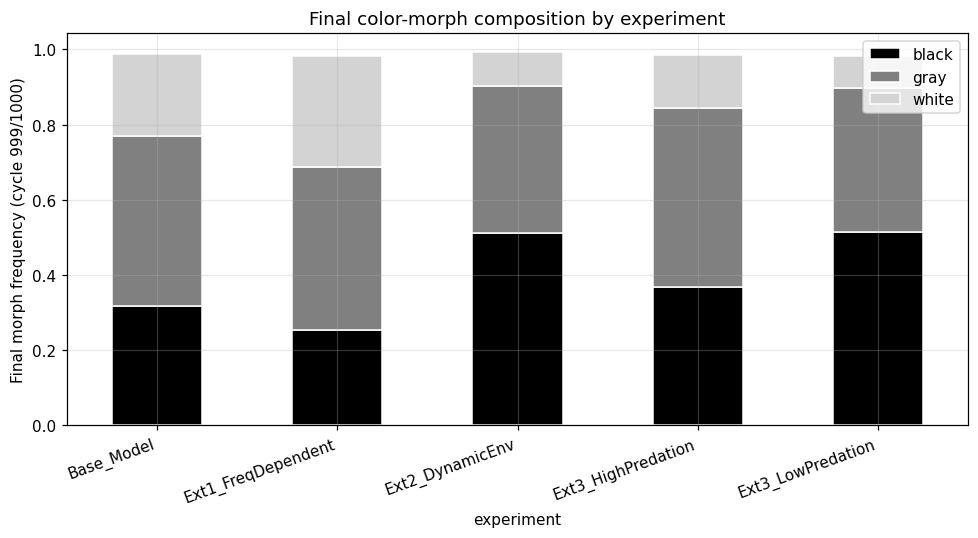

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
final_df[["final_freq_black", "final_freq_gray", "final_freq_white"]].plot(
    kind="bar", stacked=True, ax=ax, color=["black", "gray", "lightgray"], edgecolor="white")
ax.set_ylabel("Final morph frequency (cycle 999/1000)")
ax.set_title("Final color-morph composition by experiment")
ax.set_xticklabels(final_df.index, rotation=20, ha="right")
ax.legend(["black", "gray", "white"], loc="upper right")
plt.tight_layout()
plt.savefig("eda_final_morph_comparison.png", bbox_inches="tight")
plt.show()


## 6. Rolling volatility of allele frequency

50-cycle rolling standard deviation of allele-B frequency — a proxy for how strongly/erratically each mechanism perturbs the gene pool (e.g. Extension2's moving gradient should show periodic swings).

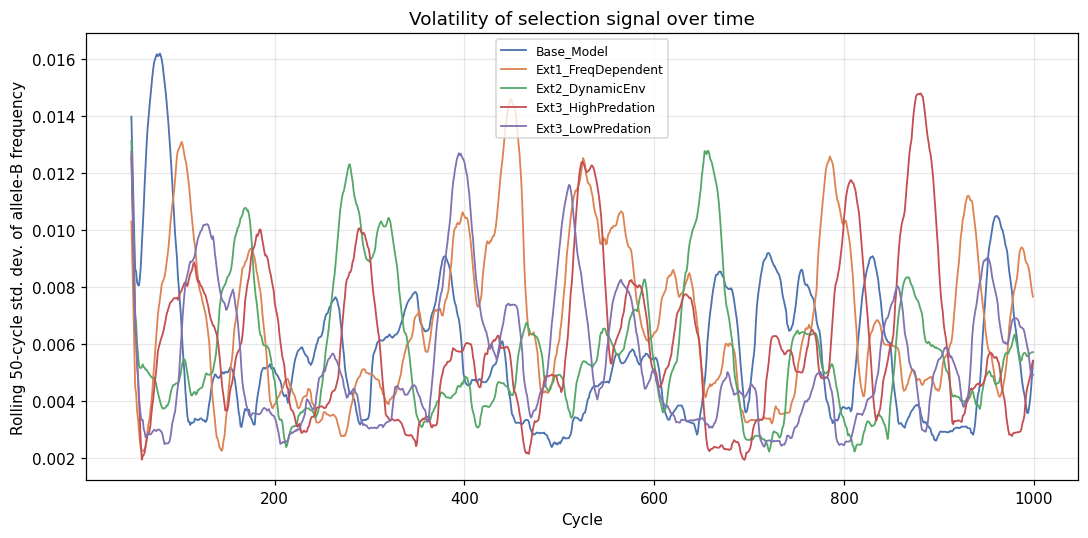

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, df in dfs.items():
    roll = df["freq_allele_B"].rolling(50).std()
    ax.plot(df["cycle"], roll, label=name, color=COLORS[name], linewidth=1.2)
ax.set_xlabel("Cycle")
ax.set_ylabel("Rolling 50-cycle std. dev. of allele-B frequency")
ax.set_title("Volatility of selection signal over time")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("eda_allele_volatility.png", bbox_inches="tight")
plt.show()


## 7. Summary of findings

- **Base_Model** (static gradient + uniform predation): camouflage-driven selection — butterflies whose
  color matches their local patch survive better, so genotype frequencies drift toward whatever the
  local environment favors instead of collapsing to a single morph; gray (heterozygote) is a "generalist"
  well-matched to intermediate/gradient patches.
- **Extension1 (frequency-dependent predation)** applies negative frequency-dependent selection: the
  *most common* color is preferentially hunted, which is expected to actively suppress whichever morph
  becomes dominant and push the population toward a more even three-way morph balance (balancing selection)
  compared to the baseline.
- **Extension2 (dynamic environment)** slides the camouflage gradient across the grid over time, so the
  locally optimal color class keeps changing — expect higher volatility (see §6) in allele frequency than
  the static baseline, since selection pressure reverses direction periodically instead of settling.
- **Extension3 (predation intensity)**: comparing High (`0.9`) vs Low (`0.15`) capture probability isolates
  the effect of *predation strength* independent of its selectivity mechanism. High predation should show
  much higher `pct_deaths_from_predation`, likely a lower/more volatile equilibrium population (capture
  events matter more relative to natural death and reproduction), and potentially faster fixation toward
  the better-camouflaged morph since mismatched individuals are eliminated more aggressively. Low predation
  should look closer to genetic drift, since natural death dominates and selection pressure is weak.
- All 5 runs share identical initial conditions (200 individuals, 50/50 allele frequency, `carrying_capacity=600`),
  so the comparison in §5 isolates the effect of *only* the varied mechanism on final morph composition and
  net allele-B frequency shift.

See the numeric tables in §1, §4, and §5 above for the exact values behind these observations.
